# Polygon drawing

This notebook shows how to draw a polygon to define the modeling area of an archpy project using ArchPy functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import geone
import geone.covModel as gcm
import geopandas as gpd
import pandas as pd
import geone.imgplot3d as imgplt3

# autoreload
%load_ext autoreload
%autoreload 2


import sys
import os

try:
    import ArchPy
except: # if ArchPy is not installed
    print("ArchPy not installed")
    sys.path.append("../..")
    import ArchPy

ArchPy not installed


Let's first create an Arch_table

In [2]:
T1 = ArchPy.base.Arch_table(name = "draw_poly", working_directory="Archpy_workspace", seed = 10, verbose = 1)

## Data

First thing to do is to open the data files and to plot them on a map that will serve as a background map for the drawing of the modeling area

In [3]:
folder = "./data_files/"
l_bh_path = pd.read_csv(os.path.join(folder, f"P1.lbh"))

unit_data_path = pd.read_csv(os.path.join(folder, f"P1.ud"))

facies_data_path = pd.read_csv(os.path.join(folder, f"P1.fd"))
db, l_bhs = ArchPy.inputs.load_bh_files(list_bhs=l_bh_path,
                            units_data=unit_data_path, u_ID="Strat",
                            facies_data=facies_data_path,
                              altitude=True)

To do the selection, we first need to create an object that will allow us to draw the polygon. This is done by calling ``DrawPoly`` from ArchPy.inputs.


In [4]:
obj = ArchPy.inputs.drawPoly()

Then we create a figure that represents a top view of our modeling area and add whatever we want on it. Here we will only display borehole locations, but you can plot total extent of the aquifer, rivers, etc. 

The important things is to plot everything using axes (e.g. ``ax = plt.gca()``) from matplotlib. And then pass this axis to ``obj.draw(ax, typ=polygon)``

``draw`` has several options, type can be either:
- polygon
- rectangle

Make sure to add ``plt.show(block = True)`` to kept this cell running while the figure is open. This will prevent further execution of code in case you have click on run all cells. Not that he works only with tk backend



In [5]:
%matplotlib tk

fig = plt.Figure(figsize=(10, 10))
ax = plt.gca()
ax.scatter(l_bhs.bh_x, l_bhs.bh_y)

obj.draw(ax, typ="polygon")
plt.show(block = True)

Select your region
Use left button to select you area(s)
Polygon added - please press esc if you want to draw another or close the window when you have finished


Now the list of points can be retrieved in the attributes ``.list_p`` from ``obj``

Add last point to close the polygon (to fix in archpy)

In [6]:
obj.list_p[0].append(obj.list_p[0][0])

In [7]:
list_p = np.array(obj.list_p[0])  # put into array

In [8]:
# create a polygon
from shapely.geometry import Polygon
smaller_extent = Polygon(list_p)

Display the polygon

(-5.0, 55.0)

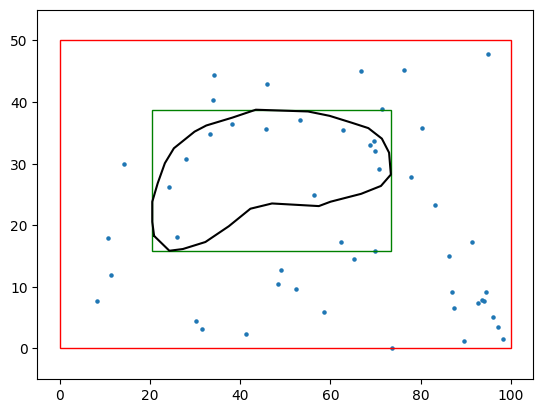

In [25]:
%matplotlib inline
fig = plt.Figure(figsize=(10, 10))
ax = plt.gca()
ax.scatter(l_bhs.bh_x, l_bhs.bh_y, s=5)

# plot polygon
x, y = smaller_extent.exterior.coords.xy
plt.plot(x, y, color="k")

# plot rectangle around modeling area
plt.gca().add_patch(plt.Rectangle((smaller_extent.bounds[0], smaller_extent.bounds[1]),
                                   smaller_extent.bounds[2] - smaller_extent.bounds[0],
                                   smaller_extent.bounds[3] - smaller_extent.bounds[1],
                                     fill=None, edgecolor='g'))

# plot whole area rectangle between 0 - 100 and 0 - 50
plt.gca().add_patch(plt.Rectangle((0, 0), 100, 50, fill=None, edgecolor='r'))

plt.xlim(-5, 105)
plt.ylim(-5, 55)

Now we can define the grid and everything

Pay attention than the grid you will create needs to integrate the polygon you just draw. If your grid is larger, you will use more cells than required and otherwise, your polygon will fall outside of your grid.
A good practice is to define the bounds of the grid at the same bounds than the polygon.

In [35]:
#grid
sx = 0.75
sy = 0.75
sz = .5
x1 = smaller_extent.bounds[2]
y1 = smaller_extent.bounds[3]
z1 = -6
x0 = smaller_extent.bounds[0]
y0 = smaller_extent.bounds[1]
z0 = -15
Lx = x1 - x0
Ly = y1 - y0
Lz = z1 - z0

nx = int(Lx/sx)
ny = int(Ly/sy)
nz = int(Lz/sz)

dimensions = (nx, ny, nz)
spacing = (sx, sy, sz)
origin = (x0, y0, z0)  

top = np.ones([ny,nx])*-6
bot = np.ones([ny,nx])*z0

In [36]:
T1.add_grid(dimensions, spacing, origin, top=top, bot=bot, polygon=smaller_extent)

## Adding Grid ##
Polygon is a shapely instance - discretization activated
## Grid added and is now simulation grid ##


In [37]:
pv.set_jupyter_backend("static")

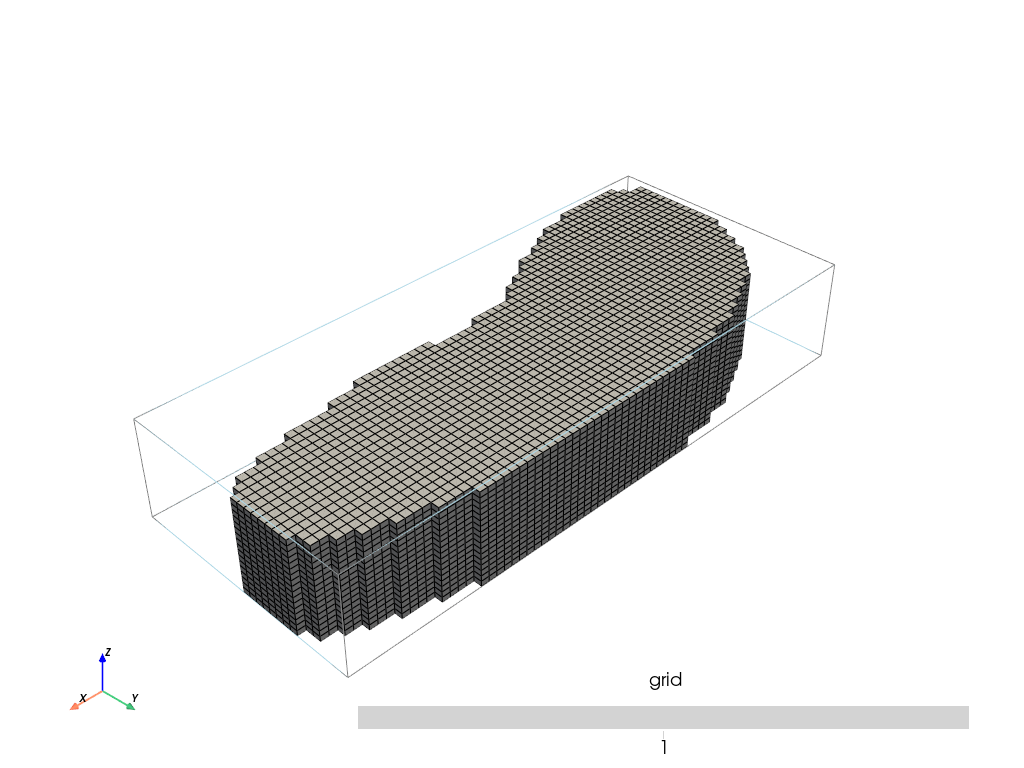

In [38]:
T1.plot_grid()

Now you can create your table and setup your parameter as you want!